C:\Users\MSI\AppData\Local\Temp\ipykernel_10700\1448245948.py:51: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')


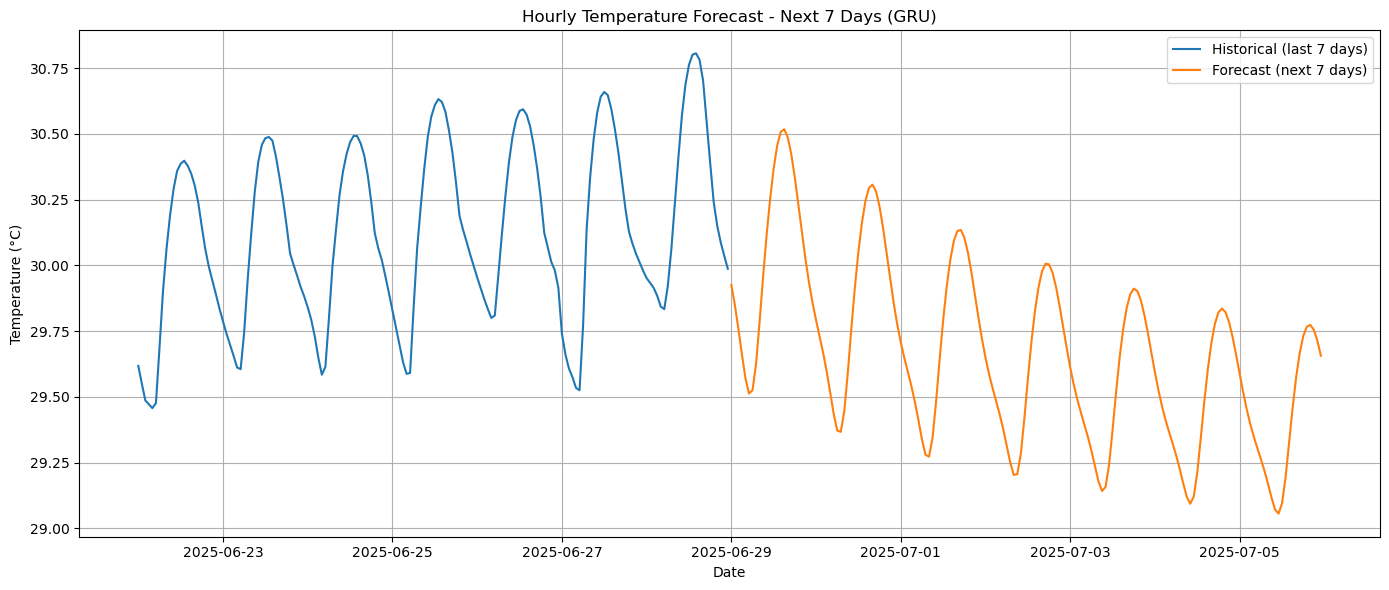

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import joblib

df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'], index_col='valid_time')

t2m = df['t2m'].values.reshape(-1, 1)

scaler = joblib.load("../models/scalers/minmax_scaler.pkl")
t2m_scaled = scaler.transform(t2m)

gru_model = keras.models.load_model("../models/dl/gru_model.keras")  


forecast_horizon = 24 * 7 
timesteps = 24  

current_sequence = t2m_scaled[-timesteps:].reshape(1, timesteps, 1) 
forecast = []

for _ in range(forecast_horizon):
    pred = gru_model.predict(current_sequence, verbose=0)  
    pred_value = pred[0][0]  

   
    pred_real = scaler.inverse_transform([[pred_value]])[0][0]
    forecast.append(pred_real)

  
    current_sequence = np.append(current_sequence[:, 1:, :], [[[pred_value]]], axis=1)


last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')

forecast_df = pd.DataFrame({
    "valid_time": forecast_index,
    "t2m_forecast": forecast
})

plt.figure(figsize=(14, 6))
plt.plot(df.index[-7*24:], df['t2m'].values[-7*24:], label='Historical (last 7 days)')
plt.plot(forecast_index, forecast, label='Forecast (next 7 days)')
plt.title('Hourly Temperature Forecast - Next 7 Days (GRU)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
forecast_df.to_csv("../data/predictions/sfax_forecast_next7days.csv",index=False)